# Valencia sidewalk routing — accessibility model demo

Exercises the accessibility-aware routing pipeline:

1. **Citywide maps** — where Valencia's sidewalks are wide enough, and how the slope penalty inflates `alt_distance`.
2. **Per-edge distributions** — slope and cost-multiplier histograms with the CTE / DB-SUA thresholds marked.
3. **Route comparison** — several origin/destination pairs routed both by raw `distance` and by the accessibility-weighted `alt_distance`.

The cost model is Option 2 from `docs/alt_distance_proposal.pdf`:

$$\text{alt\_distance} \;=\; \text{distance}\cdot \exp\!\bigl(k_{\uparrow}\,\max(s,0) + k_{\downarrow}\,\max(-s,0)\bigr)\,\big/\,10^{A}$$

with CTE-anchored defaults $k_{\uparrow}=38,\ k_{\downarrow}=23$ and $A\in\{0,1\}$ the width gate ($w \ge 1{,}50\,\text{m}$).

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from shapely.geometry import Point

from src.network import Network

DB_PATH = "data/network.duckdb"
network = Network(DB_PATH)

# Materialise every edge geometry once so every plot below can use the
# same backdrop without re-decoding WKB.
edges_gdf = network.edges.copy()
edges_gdf["geometry"] = edges_gdf.apply(network.get_linestring, axis=1)
edges_gdf = gpd.GeoDataFrame(edges_gdf, geometry="geometry", crs=network.crs)

# Derived columns used throughout the notebook.
edges_gdf["ratio"]     = edges_gdf["alt_distance"] / edges_gdf["distance"]
edges_gdf["abs_slope"] = edges_gdf["slope"].abs()

print(f"Loaded {len(network.nodes):,} nodes / {len(edges_gdf):,} edges in {network.crs}")

Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 286829
Setting CH edge vector of size 475450
Range graph removed 475472 edges of 950900
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
 100% Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 286829
Setting CH edge vector of size 475450
Range graph removed 475472 edges of 950900
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
 100% Loaded 286,829 nodes / 475,450 edges in EPSG:25830


## Network overview

Summary statistics for the columns that drive routing.

In [2]:
edges_gdf[["distance", "alt_distance", "ratio", "width", "slope", "accesibility"]].describe().T

,count,mean,std,min,25%,50%,75%,max
distance,475450.0,13.504065,29.759830,4.907427e-09,3.110333,6.944817,14.597071,1360.171745
alt_distance,475450.0,236.147790,3086.384878,4.907427e-10,0.323359,0.759896,2.079648,257620.842285
ratio,475450.0,69.327080,743.039550,1.000000e-01,0.100000,0.100000,0.100000,8932.172336
width,475450.0,6.105257,2.780548,2.400000e+00,4.020438,5.416191,7.639702,12.000000
slope,475450.0,0.000000,0.114185,-2.301429e+01,0.000000,0.000000,0.000000,23.014287
accesibility,475450.0,1.000000,0.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000


## Citywide accessibility (width gate)

Binary `accesibility` column: 1 when `width ≥ 1.50 m` (the TMA/851 *estrechamiento puntual* limit), 0 otherwise.

/var/folders/y4/36wfzpkn3zj_yfdqyjvfd0x00000gn/T/ipykernel_58811/3272336570.py:2: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  edges_gdf[edges_gdf["accesibility"] == 0].plot(


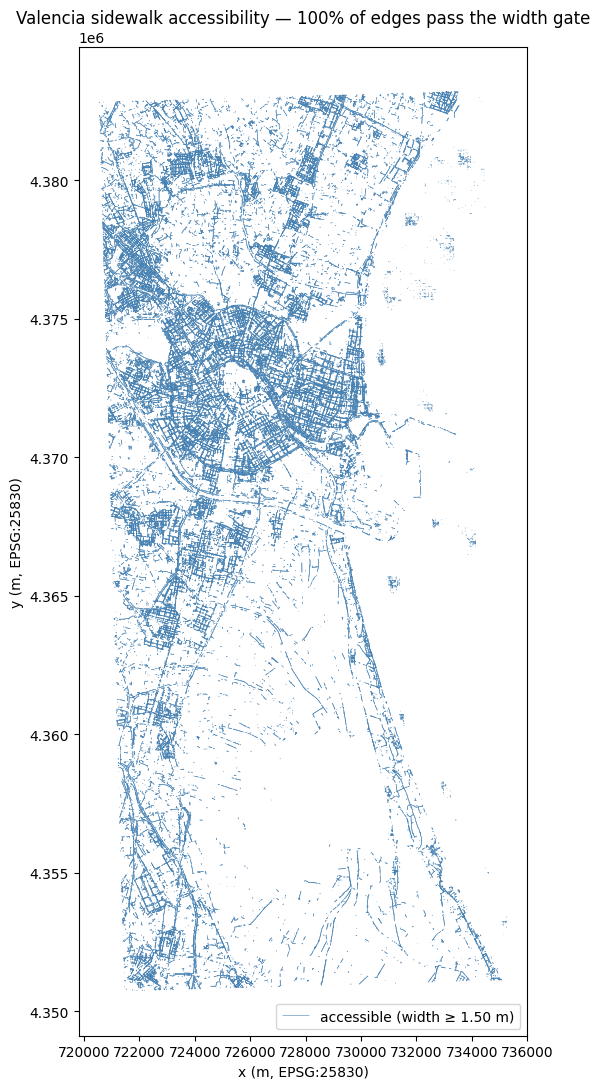

In [3]:
fig, ax = plt.subplots(figsize=(11, 11))
edges_gdf[edges_gdf["accesibility"] == 0].plot(
    ax=ax, color="lightcoral", linewidth=0.4, label="not accessible (width < 1.50 m)",
)
edges_gdf[edges_gdf["accesibility"] == 1].plot(
    ax=ax, color="steelblue", linewidth=0.4, label="accessible (width \u2265 1.50 m)",
)
share = (edges_gdf["accesibility"] == 1).mean() * 100
ax.set_aspect("equal")
ax.set_title(f"Valencia sidewalk accessibility \u2014 {share:.0f}% of edges pass the width gate")
ax.set_xlabel("x (m, EPSG:25830)")
ax.set_ylabel("y (m, EPSG:25830)")
ax.legend(loc="lower right")
plt.tight_layout()

## Citywide cost multiplier

`alt_distance / distance` per edge — the inflation factor the accessibility router applies. Below 1 means *preferred* (wide and flat); above 1 means *penalised* (narrow or steep). Plotted on a log colour scale because the ratio spans roughly 0.1 (flat and wide) to ~50+ (steep and narrow).

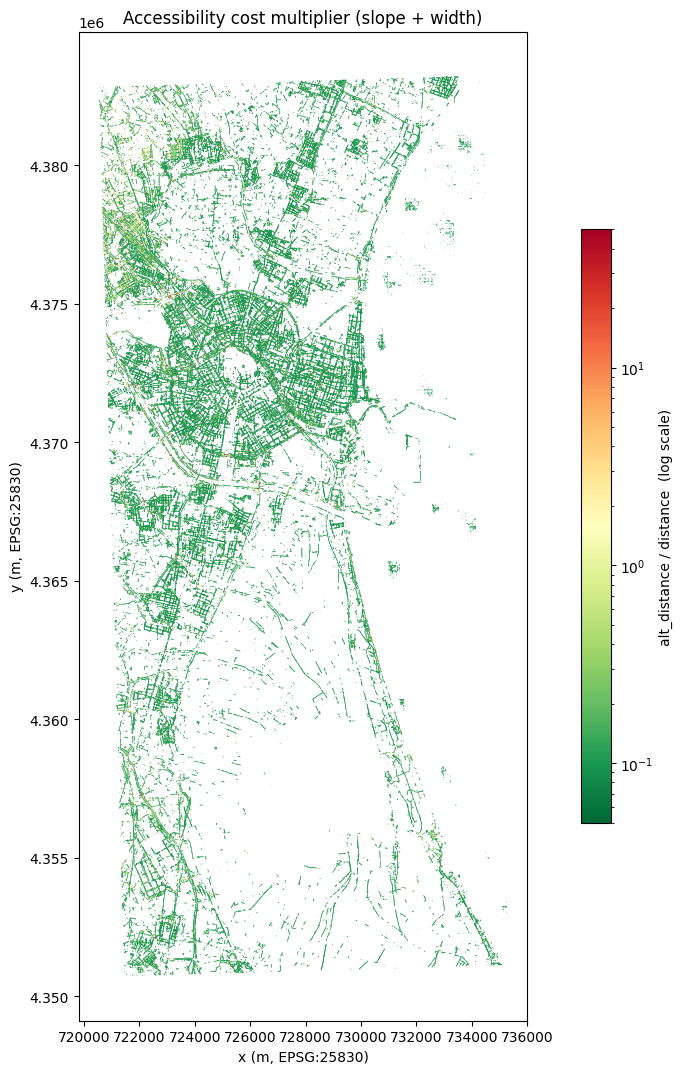

In [4]:
fig, ax = plt.subplots(figsize=(11, 11))
r = edges_gdf["ratio"].clip(lower=0.05, upper=50)
edges_gdf.assign(_r=r).plot(
    ax=ax,
    column="_r",
    cmap="RdYlGn_r",
    linewidth=0.4,
    norm=LogNorm(vmin=0.05, vmax=50),
    legend=True,
    legend_kwds={"label": "alt_distance / distance  (log scale)", "shrink": 0.6},
)
ax.set_aspect("equal")
ax.set_title("Accessibility cost multiplier (slope + width)")
ax.set_xlabel("x (m, EPSG:25830)")
ax.set_ylabel("y (m, EPSG:25830)")
plt.tight_layout()

## Distributions

Where on the slope and cost-multiplier curves do Valencia's sidewalks land? Red/dark-red lines mark the CTE DB-SUA / Orden TMA/851 thresholds (6% itinerario peatonal accesible, 10% rampa corta máx.).

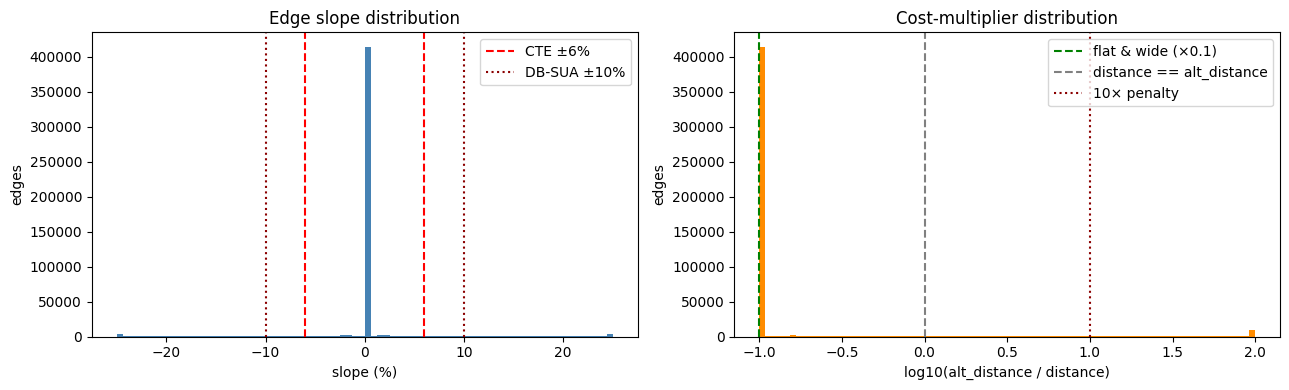

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))

slopes_pct = edges_gdf["slope"].dropna() * 100
axs[0].hist(slopes_pct.clip(-25, 25), bins=80, color="steelblue")
axs[0].axvline( 6,  color="red",     linestyle="--", label="CTE \u00b16%")
axs[0].axvline(-6,  color="red",     linestyle="--")
axs[0].axvline( 10, color="darkred", linestyle=":",  label="DB-SUA \u00b110%")
axs[0].axvline(-10, color="darkred", linestyle=":")
axs[0].set_xlabel("slope (%)")
axs[0].set_ylabel("edges")
axs[0].set_title("Edge slope distribution")
axs[0].legend()

log_ratio = np.log10(edges_gdf["ratio"].clip(0.01, 100))
axs[1].hist(log_ratio, bins=80, color="darkorange")
axs[1].axvline(np.log10(0.1), color="green",   linestyle="--", label="flat & wide (\u00d70.1)")
axs[1].axvline(0,             color="grey",    linestyle="--", label="distance == alt_distance")
axs[1].axvline(1,             color="darkred", linestyle=":",  label="10\u00d7 penalty")
axs[1].set_xlabel("log10(alt_distance / distance)")
axs[1].set_ylabel("edges")
axs[1].set_title("Cost-multiplier distribution")
axs[1].legend()
plt.tight_layout()

## Routing comparison

Pick several origin/destination pairs in the same connected component and route them both ways. The primary route minimises raw `distance`; the alternate minimises `alt_distance`, so it should detour around steep or narrow segments.

Note: the tile2net source graph is heavily fragmented at kerb crossings, so candidate pairs are sampled only from components of at least 100 nodes.

In [6]:
# Build a node->component map so any pair we draw is guaranteed routable.
g = nx.from_pandas_edgelist(network.edges, source="from", target="to")
components = sorted(nx.connected_components(g), key=len, reverse=True)
print(f"{len(components):,} components; largest 5 sizes: {[len(c) for c in components[:5]]}")

candidate_comps = [list(c) for c in components if len(c) >= 100]
flat_candidates = np.array([n for c in candidate_comps for n in c])
comp_id = {n: i for i, c in enumerate(candidate_comps) for n in c}
print(f"Sampling pairs from {len(candidate_comps)} components ({len(flat_candidates):,} nodes total)")

def pick_diverging_pair(rng, attempts: int = 400):
    """Return (origin_xy, dest_xy, primary_gdf, alt_gdf) where the two routes differ."""
    for _ in range(attempts):
        n1, n2 = rng.choice(flat_candidates, size=2, replace=False)
        if comp_id[n1] != comp_id[n2]:
            continue
        o = (network.nodes.at[n1, "x"], network.nodes.at[n1, "y"])
        d = (network.nodes.at[n2, "x"], network.nodes.at[n2, "y"])
        p_ids = network.route(o, d, alternate=False)
        a_ids = network.route(o, d, alternate=True)
        if p_ids is None or a_ids is None or np.array_equal(p_ids, a_ids):
            continue
        return o, d, network.route_gdf(o, d, alternate=False), network.route_gdf(o, d, alternate=True)
    return None

rng = np.random.default_rng(seed=2026)
N_PAIRS = 4
pairs = []
while len(pairs) < N_PAIRS:
    found = pick_diverging_pair(rng)
    if found is None:
        print("Couldn't find another diverging pair within budget; stopping.")
        break
    pairs.append(found)
    _, _, p, a = found
    detour = (a["distance"].sum() / p["distance"].sum() - 1) * 100
    print(f"  pair {len(pairs)}: primary={p['distance'].sum():6.0f} m   alt={a['distance'].sum():6.0f} m   detour={detour:+5.1f}%")

51,411 components; largest 5 sizes: [515, 374, 333, 298, 239]
Sampling pairs from 50 components (8,170 nodes total)
  pair 1: primary=   636 m   alt=   773 m   detour=+21.5%
  pair 2: primary=   269 m   alt=   776 m   detour=+188.7%
  pair 3: primary=   252 m   alt=   410 m   detour=+62.7%
  pair 4: primary=   744 m   alt=   881 m   detour=+18.4%


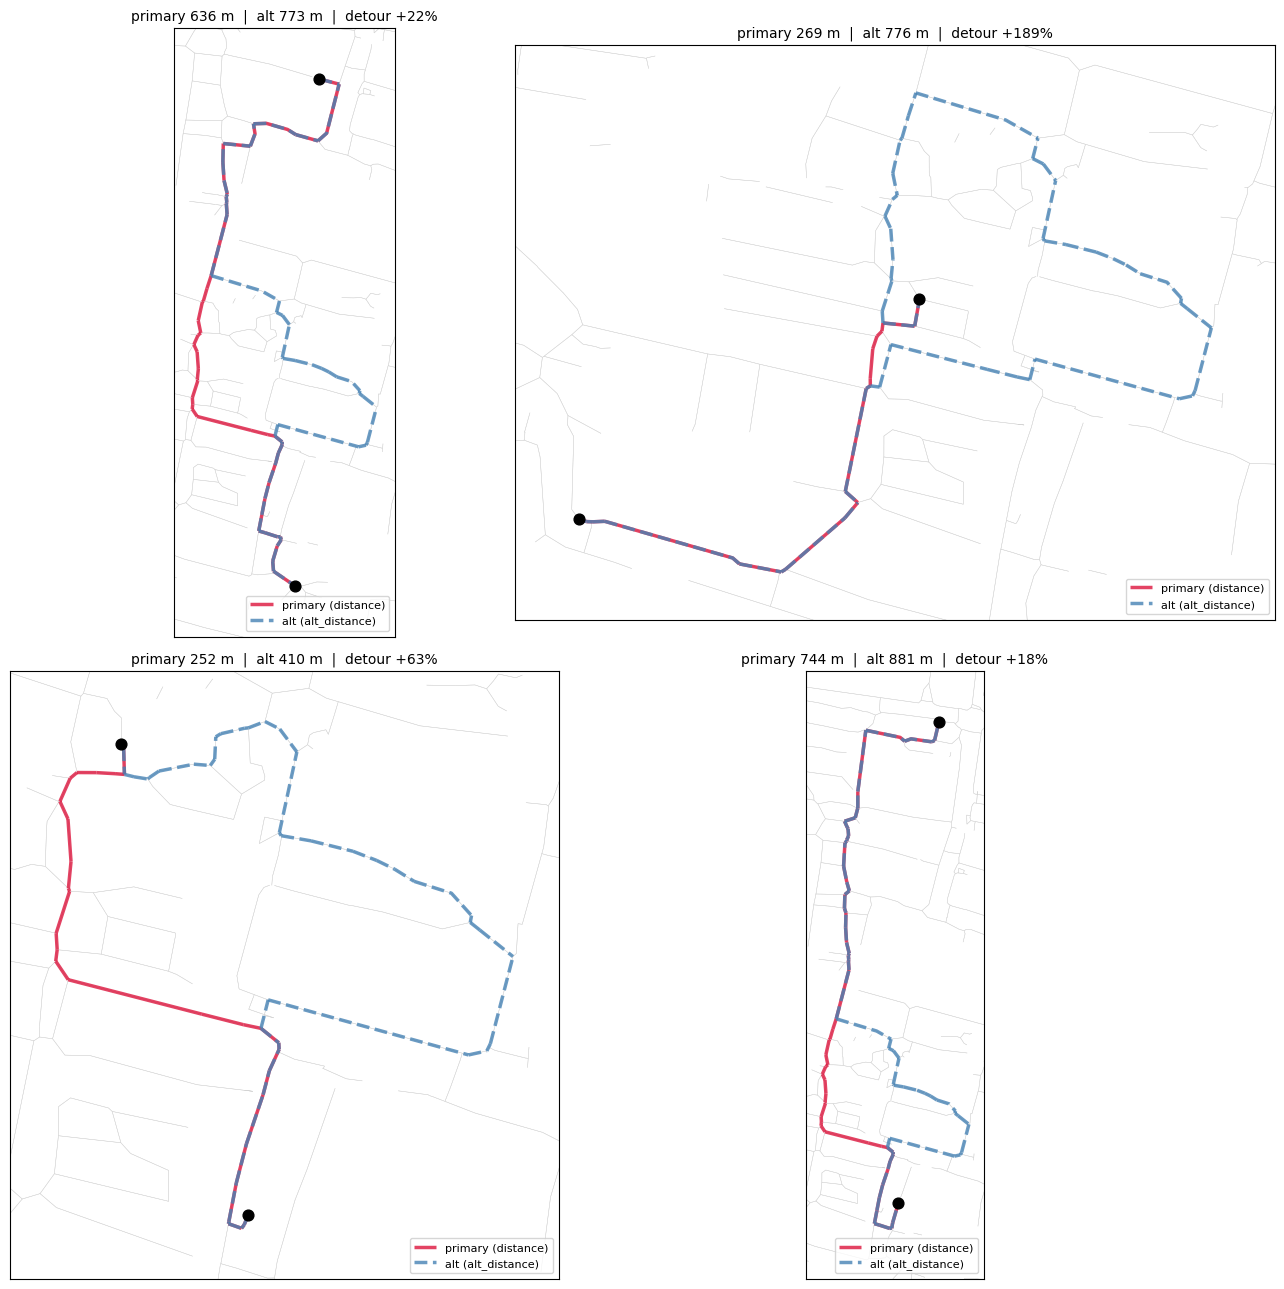

In [7]:
def local_backdrop(edges, bbox, pad=0.15):
    """Spatial slice of `edges` covering `bbox` (+ padding) so we don't redraw all 475k lines."""
    minx, miny, maxx, maxy = bbox
    mx, my = (maxx - minx) * pad, (maxy - miny) * pad
    return edges.cx[minx - mx:maxx + mx, miny - my:maxy + my]

rows = (len(pairs) + 1) // 2
fig, axs = plt.subplots(rows, 2, figsize=(14, 6.5 * rows))
axs = np.atleast_2d(axs).flatten()

for i, (o, d, primary, alt) in enumerate(pairs):
    ax = axs[i]
    b1, b2 = primary.total_bounds, alt.total_bounds
    bbox = (
        min(b1[0], b2[0]), min(b1[1], b2[1]),
        max(b1[2], b2[2]), max(b1[3], b2[3]),
    )
    local_backdrop(edges_gdf, bbox).plot(ax=ax, color="lightgrey", linewidth=0.3)
    primary.plot(ax=ax, color="crimson",   linewidth=2.5, alpha=0.8, label="primary (distance)")
    alt.plot(    ax=ax, color="steelblue", linewidth=2.5, alpha=0.8, linestyle="--", label="alt (alt_distance)")
    gpd.GeoDataFrame(
        {"k": ["O", "D"]}, geometry=[Point(*o), Point(*d)], crs=network.crs,
    ).plot(ax=ax, color="black", markersize=60, zorder=5)
    mx, my = (bbox[2] - bbox[0]) * 0.10, (bbox[3] - bbox[1]) * 0.10
    ax.set_xlim(bbox[0] - mx, bbox[2] + mx)
    ax.set_ylim(bbox[1] - my, bbox[3] + my)
    ax.set_aspect("equal")
    detour = (alt["distance"].sum() / primary["distance"].sum() - 1) * 100
    ax.set_title(
        f"primary {primary['distance'].sum():.0f} m  |  alt {alt['distance'].sum():.0f} m  |  detour {detour:+.0f}%",
        fontsize=10,
    )
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="lower right", fontsize=8)

for j in range(len(pairs), len(axs)):
    axs[j].set_visible(False)
plt.tight_layout()

### Summary table

Per-pair quantitative comparison: total distance, percent detour, the worst slope segment the route traverses, and the narrowest sidewalk segment.

In [8]:
summary = []
for i, (o, d, primary, alt) in enumerate(pairs, start=1):
    summary.append({
        "pair":              i,
        "primary_m":         primary["distance"].sum(),
        "alt_m":             alt["distance"].sum(),
        "detour_%":          (alt["distance"].sum() / primary["distance"].sum() - 1) * 100,
        "primary_max_|s|_%": primary["slope"].abs().max() * 100,
        "alt_max_|s|_%":     alt["slope"].abs().max() * 100,
        "primary_min_w_m":   primary["width"].min(),
        "alt_min_w_m":       alt["width"].min(),
    })
pd.DataFrame(summary).round(2)

,pair,primary_m,alt_m,detour_%,primary_max_|s|_%,alt_max_|s|_%,primary_min_w_m,alt_min_w_m
0,1,636.14,773.20,21.54,25.30,14.67,6.26,6.26
1,2,268.70,775.82,188.73,29.88,14.67,8.08,9.00
2,3,252.02,409.96,62.67,25.30,14.67,12.00,9.00
3,4,744.31,881.37,18.41,25.30,14.67,6.26,6.26
